# 🏛️ Curso de Análisis No Lineal de Estructuras
## Análisis Estático No Lineal (Pushover) - Pórtico Completamente Regular
**Profesor:** Orlando Arroyo | **Entorno:** Google Colab / Jupyter Notebook

Este cuaderno implementa el análisis Pushover de un pórtico 2D de concreto reforzado **completamente regular en secciones y pisos**:
- **Geometría regular:** 3 vanos de 6.0 m y 7 pisos de 3.0 m ($H_{total} = 21.0\text{ m}$).
- **Secciones regulares:** Una sola sección de columna ($55\times 55\text{ cm}$) y una sola sección de viga ($45\times 50\text{ cm}$) para toda la estructura.
- **Comportamiento no lineal:** Concreto confinado (Mander con regularización) y acero con pandeo (Dhakal & Maekawa).
- **Diafragmas rígidos:** Activos en el 100% de los pisos.
- **Cargas y masas homogéneas:** Carga uniforme de entrepisos ($-70\text{ kN/m}$), cubierta ($-50\text{ kN/m}$) y masas nodales de $20\text{ ton}$.
- **Método N2 (Fajfar, 2000):** Obtención del factor de participación modal $\Gamma_1$ y transformación a la curva SDOF equivalente.
- **Post-procesamiento:** Curva Pushover MDOF vs SDOF, perfil regular de derivas y diagrama del modelo.

### 📦 1. Instalación Automática de Dependencias en Google Colab

In [ ]:
# Detección del entorno: Instalar paquetes solo en Google Colab
import sys
IN_COLAB = 'google.colab' in sys.modules
if not IN_COLAB:
    try:
        import google.colab
        IN_COLAB = True
    except ImportError:
        IN_COLAB = False

if IN_COLAB:
    !pip install -q openseespy opseestools opsvis matplotlib numpy pandas scipy
    print("✅ Dependencias instaladas en Google Colab.")
else:
    print("💻 Ejecución local detectada: Se omite pip para proteger tu entorno (openseespy-mac-arm).")


💻 Ejecución local detectada: Se omite pip para proteger tu entorno (openseespy-mac-arm).


### 📚 2. Importación de Librerías y Configuración

In [2]:
from openseespy.opensees import *
import matplotlib.pyplot as plt
import opseestools.analisis as an
import opseestools.utilidades as ut
import opsvis as opsv
import numpy as np
import pandas as pd

# Configuración gráfica
%matplotlib inline
plt.rcParams["figure.dpi"] = 100
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except:
    plt.style.use("default")
print("✅ Librerías cargadas exitosamente.")

✅ Librerías cargadas exitosamente.


### 📐 3. Geometría Completamente Regular
- 3 vanos de $6.0\text{ m}$ ($X = 0.0, 6.0, 12.0, 18.0\text{ m}$).
- 7 pisos de $3.0\text{ m}$ ($Y = 0.0, 3.0, 6.0, \dots, 21.0\text{ m}$).
- Base empotrada ($Y = 0$).

In [ ]:
wipe()
model("basic", "-ndm", 2, "-ndf", 3)

coordx = [0.0, 6.0, 12.0, 18.0]        # 3 vanos de 6m
coordy = [3.0 * i for i in range(8)]    # 7 pisos de 3m

ut.creategrid(coordx, coordy)
fixY(0.0, 1, 1, 1)

n_bays = len(coordx) - 1
n_stories = len(coordy) - 1
print(f"Estructura: {n_bays} vanos y {n_stories} pisos (Altura total = {coordy[-1]} m).")

Estructura regular: 3 vanos y 7 pisos (Altura total = 21.0 m).


### 🧱 4. Materiales No Lineales

In [4]:
fc = 28   # MPa
fy = 420  # MPa

tag_noconf, tag_conf, tag_acero = ut.col_materials(fc, fy, detailing="DMO", nps=3)
print(f"Materiales asignados -> Concreto no confinado: {tag_noconf}, Confinado: {tag_conf}, Acero: {tag_acero}")

Materiales asignados -> Concreto no confinado: 102, Confinado: 101, Acero: 100


### 📏 5. Secciones Regulares Únicas (Vigas y Columnas)
- **Columna única para todos los pisos:** $55\times 55\text{ cm}$ (5 #8 superior, 5 #8 inferior, 6 #8 laterales).
- **Viga única para todos los pisos:** $45\times 50\text{ cm}$ (9 #6 superior, 5 #4 inferior).

In [5]:
Bcol, Hcol = 0.55, 0.55  # Columna regular [m]
Bvig, Hvig = 0.45, 0.50  # Viga regular [m]
c = 0.05                 # Recubrimiento [m]

As4 = 0.000127 # #4
As6 = 0.000280 # #6
As8 = 0.000508 # #8

col_sec = 101
vig_sec = 201

ut.create_rect_RC_section(col_sec, Hcol, Bcol, c, tag_conf, tag_noconf, tag_acero, 5, As8, 5, As8, 6, As8)
ut.create_rect_RC_section(vig_sec, Hvig, Bvig, c, tag_conf, tag_noconf, tag_acero, 9, As6, 5, As4)
print("Secciones regulares definidas: Columna 55x55 (101) y Viga 45x50 (201).")

Secciones regulares definidas: Columna 55x55 (101) y Viga 45x50 (201).


### 🏢 6. Ensamblaje Regular de Elementos y Diafragmas

In [6]:
tagcols, tagbeams = ut.create_elements(coordx, coordy, col_sec, vig_sec, dia=1)
print(f"Estructura ensamblada: {len(tagcols)} columnas ({n_bays+1}x{n_stories}) y {len(tagbeams)} vigas ({n_bays}x{n_stories}). Diafragmas activos en todos los niveles.")

Estructura ensamblada: 28 columnas (4x7) y 21 vigas (3x7). Diafragmas activos en todos los niveles.


### ⚖️ 7. Cargas Gravitacionales Regulares en Vigas

In [7]:
floor_load = -70.0 # kN/m en entrepisos
roof_load  = -50.0 # kN/m en cubierta
ut.load_beams(floor_load, roof_load, tagbeams)
print(f"Cargas aplicadas: {floor_load} kN/m en entrepisos y {roof_load} kN/m en cubierta.")

Cargas aplicadas: -70.0 kN/m en entrepisos y -50.0 kN/m en cubierta.


### 🏋️ 8. Masas Nodales Homogéneas

In [8]:
default_mass = 20.0 # ton
nodes_tags = np.array(getNodeTags())
coordy_all = np.array([nodeCoord(int(i))[1] for i in nodes_tags])

for tag, y in zip(nodes_tags, coordy_all):
    if y > 0:
        mass(int(tag), default_mass, default_mass, 0.0)

print(f"✅ Masas de {default_mass} ton asignadas a los {sum(coordy_all > 0)} nodos elevados.")

✅ Masas de 20.0 ton asignadas a los 28 nodos elevados.


### 🎯 9. Análisis Modal y Método N2 (Fajfar, 2000)
Cálculo del factor modal $\Gamma = \frac{\sum m_i \phi_{1,i}}{\sum m_i \phi_{1,i}^2}$.

In [9]:
w2 = eigen(n_stories)
modal_props = modalProperties("-print", "-unorm", "-return")

periods = modal_props.get("eigenPeriod", [2*np.pi/np.sqrt(v) for v in w2])
gamma_N2 = modal_props.get("partiFactorMX", [1.287])[0]

print("="*55)
print("RESULTADOS DEL ANÁLISIS MODAL (PÓRTICO REGULAR)")
print("="*55)
for i in range(min(4, len(periods))):
    print(f"Modo {i+1}: Periodo T = {periods[i]:.4f} s | Frecuencia f = {1.0/periods[i]:.3f} Hz")
print(f"Factor de Participación Modal N2 (Modo 1): Gamma = {gamma_N2:.4f}")
print("="*55)

RESULTADOS DEL ANÁLISIS MODAL (PÓRTICO REGULAR)
Modo 1: Periodo T = 0.8974 s | Frecuencia f = 1.114 Hz
Modo 2: Periodo T = 0.2819 s | Frecuencia f = 3.548 Hz
Modo 3: Periodo T = 0.1528 s | Frecuencia f = 6.545 Hz
Modo 4: Periodo T = 0.0977 s | Frecuencia f = 10.231 Hz
Factor de Participación Modal N2 (Modo 1): Gamma = 1.2873


Using DomainModalProperties - Developed by: Massimo Petracca, Guido Camata, ASDEA Software Technology


### 🌍 10. Análisis de Gravedad y Visualización con opsvis

✅ Cargas gravitacionales aplicadas con éxito.


<Figure size 700x600 with 0 Axes>

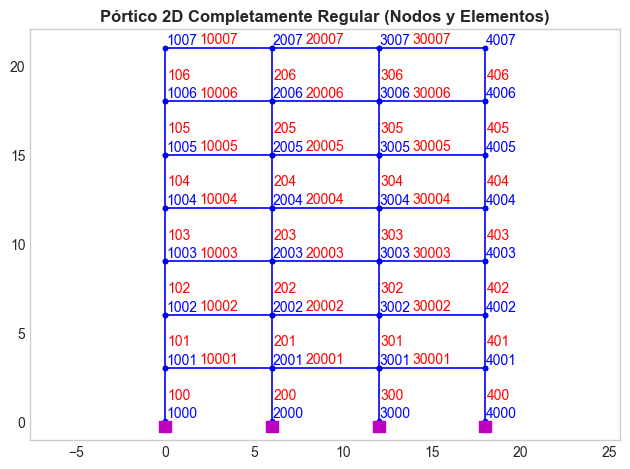

In [10]:
an.gravedad()
loadConst("-time", 0.0)
print("✅ Cargas gravitacionales aplicadas con éxito.")

plt.figure(figsize=(7, 6))
opsv.plot_model(node_labels=1, element_labels=1, gauss_points=False)
plt.title("Pórtico 2D Completamente Regular (Nodos y Elementos)", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

### 🚀 11. Ejecución del Análisis Pushover No Lineal

Iniciando Pushover controlado por desplazamiento en nodo 4007 (Dmax = 1.050 m)...
configuración por defecto no converge en desplazamiento:  0.45000000000000034
Pushover analisis fallido
Desplazamiento alcanzado:  0.45000000000000034 m
Pushover regular finalizado. D_máx = 0.4500 m | Vb_máx = 1293.49 kN


WARNING - ForceBeamColumn2d::update - failed to get compatible element forces & deformations for element: 30001(dW: << -2.45051e-05)
Domain::update - domain failed in update
DisplacementControl::update - model failed to update for new dU
WARNING NewtonRaphson::solveCurrentStep() -the Integrator failed in update()
StaticAnalysis::analyze() - the Algorithm failed at step: 0 with domain at load factor 549.906
OpenSees > analyze failed, returned: -3 error flag
WARNING - ForceBeamColumn2d::update - failed to get compatible element forces & deformations for element: 30001(dW: << -2.45063e-05)
Domain::update - domain failed in update
DisplacementControl::update - model failed to update for new dU
WARNING AcceleratedNewton::solveCurrentStep() -the Integrator failed in update()
StaticAnalysis::analyze() - the Algorithm failed at step: 0 with domain at load factor 549.793
OpenSees > analyze failed, returned: -3 error flag
WARNING - ForceBeamColumn2d::update - failed to get compatible element for

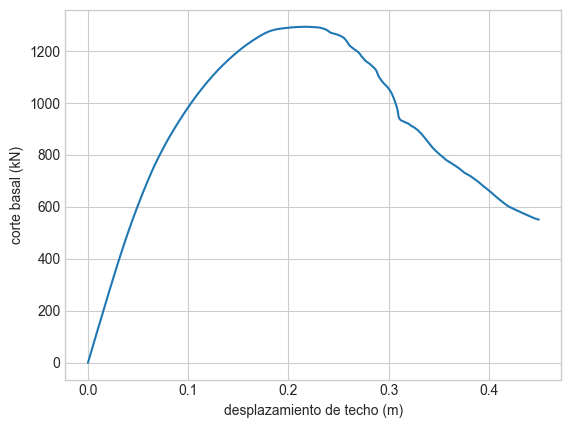

In [11]:
leftmost_nodes = ut.find_leftmost_nodes(coordy)
ut.pushover_loads(coordy, nodes=leftmost_nodes)
elements = tagcols + tagbeams
nodes_control = [1000] + [int(i) for i in leftmost_nodes]

H_total = coordy[-1]
Dmax = 0.05 * H_total
Dincr = 0.001
ctrl_node = getNodeTags()[-1]

print(f"Iniciando Pushover controlado por desplazamiento en nodo {ctrl_node} (Dmax = {Dmax:.3f} m)...")
dtecho, Vbasal, drifts, rotations = an.pushover2DRot(
    Dmax, Dincr, ctrl_node, 1, nodes_control, elements
)

dtecho = np.array(dtecho)
Vbasal = np.array(Vbasal)
story_drifts = drifts[:len(dtecho), :]

d_ult = dtecho[-1] if len(dtecho) > 0 else 0.0
v_max = max(Vbasal) if len(Vbasal) > 0 else 0.0
print(f"Pushover regular finalizado. D_máx = {d_ult:.4f} m | Vb_máx = {v_max:.2f} kN")

# SDOF equivalente N2
d_star = dtecho / gamma_N2
F_star = Vbasal / gamma_N2

### 📊 12. Gráficas Didácticas de Resultados
1. **Curva MDOF vs SDOF Equivalente N2**
2. **Perfil Regular de Derivas de Entrepiso**

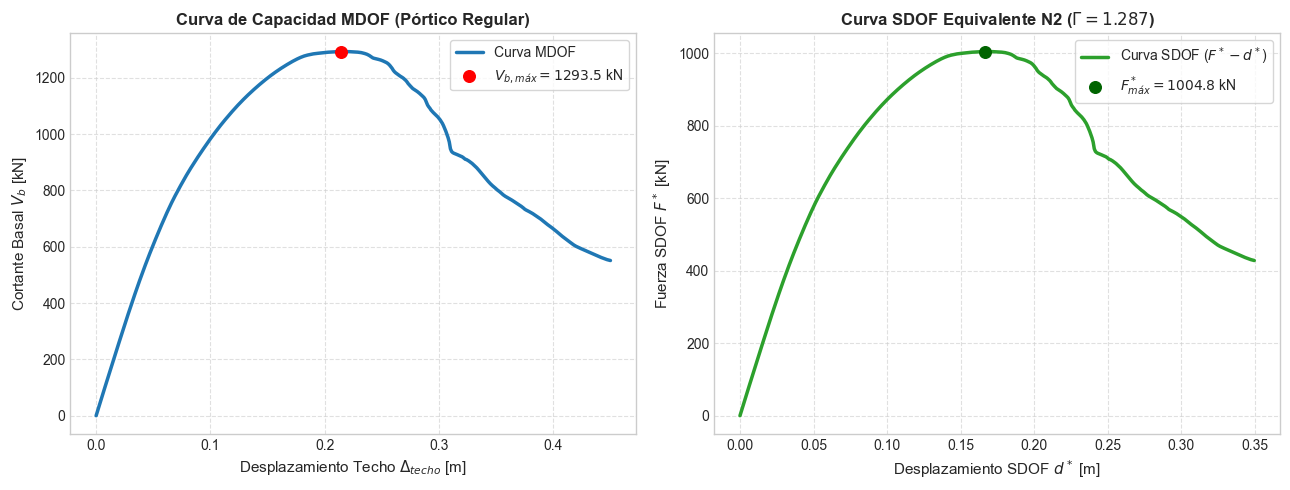

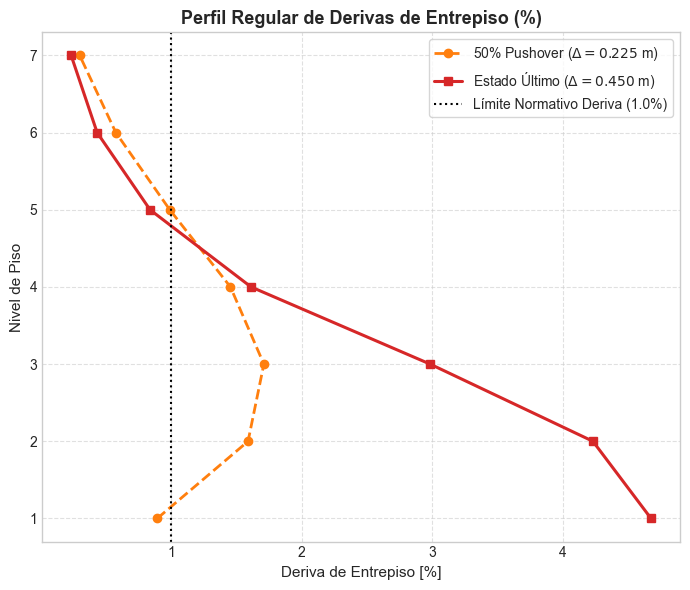

In [12]:
# 1. Curva Pushover MDOF y SDOF
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.plot(dtecho, Vbasal, color="#1f77b4", linewidth=2.5, label="Curva MDOF")
ax1.scatter([dtecho[np.argmax(Vbasal)]], [v_max], color="red", s=70, zorder=5, label=f"$V_{{b,máx}} = {v_max:.1f}$ kN")
ax1.set_title("Curva de Capacidad MDOF (Pórtico Regular)", fontsize=12, fontweight="bold")
ax1.set_xlabel(r"Desplazamiento Techo $\Delta_{techo}$ [m]", fontsize=11)
ax1.set_ylabel(r"Cortante Basal $V_b$ [kN]", fontsize=11)
ax1.grid(True, linestyle="--", alpha=0.6)
ax1.legend(frameon=True, facecolor="white", fontsize=10)

ax2.plot(d_star, F_star, color="#2ca02c", linewidth=2.5, label="Curva SDOF ($F^* - d^*$)")
ax2.scatter([d_star[np.argmax(F_star)]], [max(F_star)], color="darkgreen", s=70, zorder=5, label=f"$F^*_{{máx}} = {max(F_star):.1f}$ kN")
ax2.set_title(rf"Curva SDOF Equivalente N2 ($\Gamma = {gamma_N2:.3f}$)", fontsize=12, fontweight="bold")
ax2.set_xlabel(r"Desplazamiento SDOF $d^*$ [m]", fontsize=11)
ax2.set_ylabel(r"Fuerza SDOF $F^*$ [kN]", fontsize=11)
ax2.grid(True, linestyle="--", alpha=0.6)
ax2.legend(frameon=True, facecolor="white", fontsize=10)

plt.tight_layout()
plt.show()

# 2. Perfil de Derivas
if story_drifts.shape[1] > 0:
    plt.figure(figsize=(7, 6))
    num_floors = story_drifts.shape[1]
    floors = list(range(1, num_floors + 1))
    idx_50 = len(dtecho) // 2

    plt.plot(story_drifts[idx_50, :] * 100, floors, "o--", color="#ff7f0e", linewidth=2,
             label=rf"50% Pushover ($\Delta = {dtecho[idx_50]:.3f}$ m)")
    plt.plot(story_drifts[-1, :] * 100, floors, "s-", color="#d62728", linewidth=2.2,
             label=rf"Estado Último ($\Delta = {dtecho[-1]:.3f}$ m)")
    plt.axvline(1.0, color="black", linestyle=":", linewidth=1.5, label="Límite Normativo Deriva (1.0%)")

    plt.title("Perfil Regular de Derivas de Entrepiso (%)", fontsize=13, fontweight="bold")
    plt.xlabel("Deriva de Entrepiso [%]", fontsize=11)
    plt.ylabel("Nivel de Piso", fontsize=11)
    plt.yticks(floors)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend(frameon=True, facecolor="white", fontsize=10)
    plt.tight_layout()
    plt.show()